# Import Libraries

In [76]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# import the data

In [10]:
data=pd.read_csv('/content/spam/SPAM text message 20170820 - Data.csv')
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# undersatnding data

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [42]:
data.shape

(5572, 2)

Missing data

In [43]:
data.isna().sum()

,0
Category,0
Message,0


Duplicated data

In [67]:
data.duplicated().sum()

np.int64(415)

In [46]:
df=data.drop_duplicates(keep='first')

In [47]:
df.shape

(5157, 2)

Preparing and transforming data

In [95]:
x=df.drop(columns=['Category'])
y=df['Category']

In [98]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [99]:
y_train.shape

(4125,)

In [100]:
x_train.shape

(4125, 1)

# using the decision tree calssifier without pipline

In [101]:
tfdf=TfidfVectorizer()

In [102]:
# initiate the Decision Tree Classifier model
DecisionTreemodel=DecisionTreeClassifier()


In [92]:
#initiate the TfidfVectorizer for transform the data
tfdf=TfidfVectorizer()
tfdf

TfidfVectorizer()

In [103]:
tfdf.fit_transform(x_train['Message'])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 54608 stored elements and shape (4125, 7696)>

In [104]:
DecisionTreemodel.fit(tfdf.fit_transform(x_train['Message']),y_train)

DecisionTreeClassifier()

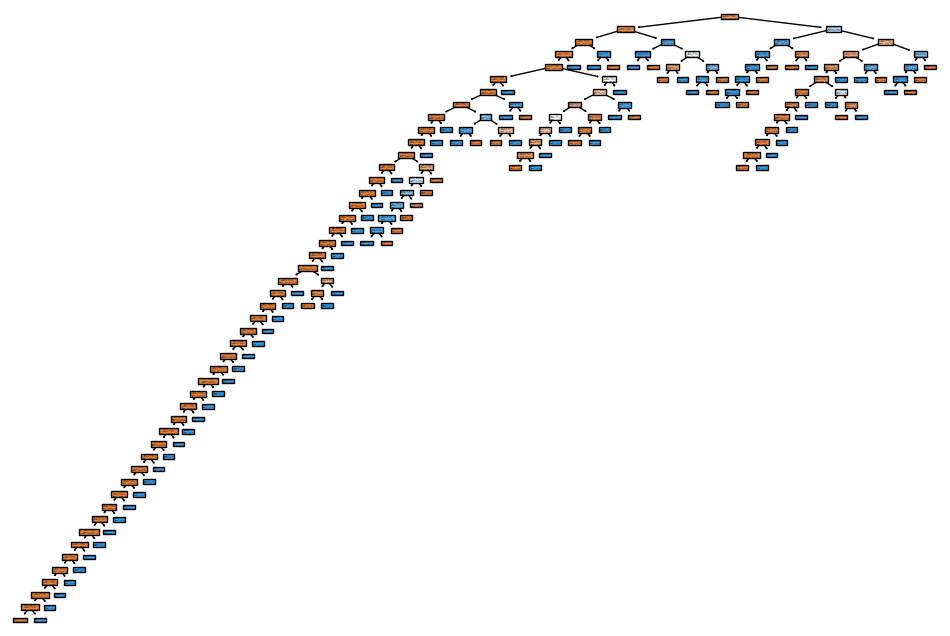

In [105]:
plt.figure(figsize=(12,8))
plot_tree(DecisionTreemodel, feature_names=tfdf.get_feature_names_out(), filled=True)
plt.show()

In [106]:
DecisionTreemodel.predict(tfdf.transform(x_test['Message']))

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

# Using the Decision  Tree Classifier by with pipline power:

In [71]:
#build the pipline uing the TfidfVectorizer and DecisionTreeClassifier
piplinetreeDeceion=Pipeline([('tfdf',TfidfVectorizer()),('clf',DecisionTreemodel)])

training the model

In [58]:
piplinetreeDeceion.fit(x_train['Message'],y_train)

Pipeline(steps=[('tfdf', TfidfVectorizer()), ('clf', DecisionTreeClassifier())])

using the model for prediction the test values

In [62]:
#predict the test values using decesion tree pipline after training
y_predections=piplinetreeDeceion.predict(x_test['Message'])

In [63]:
print("the prected values are: ",y_predections)

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

In [ ]:
print("the acuuracy score for decison tree without pipline ",DecisionTreemodel.score(tfdf.transform(x_test['Message']),y_test))

# the result , the evaluation for  decision tree model  

In [108]:
dcsntree_acuracy=accuracy_score(y_predections,y_test)
print("the accuaracy of desion tree model with pipline  =",dcsntree_acuracy)
print("the acuuracy score for decison tree without pipline ",DecisionTreemodel.score(tfdf.transform(x_test['Message']),y_test))
#the outpu the accuaracy of desion tree model = 0.9622093023255814
# fantastic result .

the accuaracy of desion tree model with pipline  = 0.9622093023255814
the acuuracy score for decison tree without pipline  0.9593023255813954


In [75]:
cls_report=classification_report(y_predections,y_test)
print(cls_report)

              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       918
        spam       0.80      0.89      0.84       114

    accuracy                           0.96      1032
   macro avg       0.89      0.93      0.91      1032
weighted avg       0.96      0.96      0.96      1032



In [ ]:
# As we watch we can improve the result by using pipline or cahnging the parameters  the result of using piline was more accuarte